# Output of the model

Here we show how to use the model on a data set. We have downloaded the data from the [Agrometeo](https://agrometeo.ch/meteorologie) and we have used the data of Changins from 1$^\text{st}$ January to 31 August 2025. The data can be found [here](https://github.com/agroscope-ch/Irrigation/blob/c12420e9afa37f1c477c69a8ccf32c0f57ee3434/data/2025_Changins.csv).

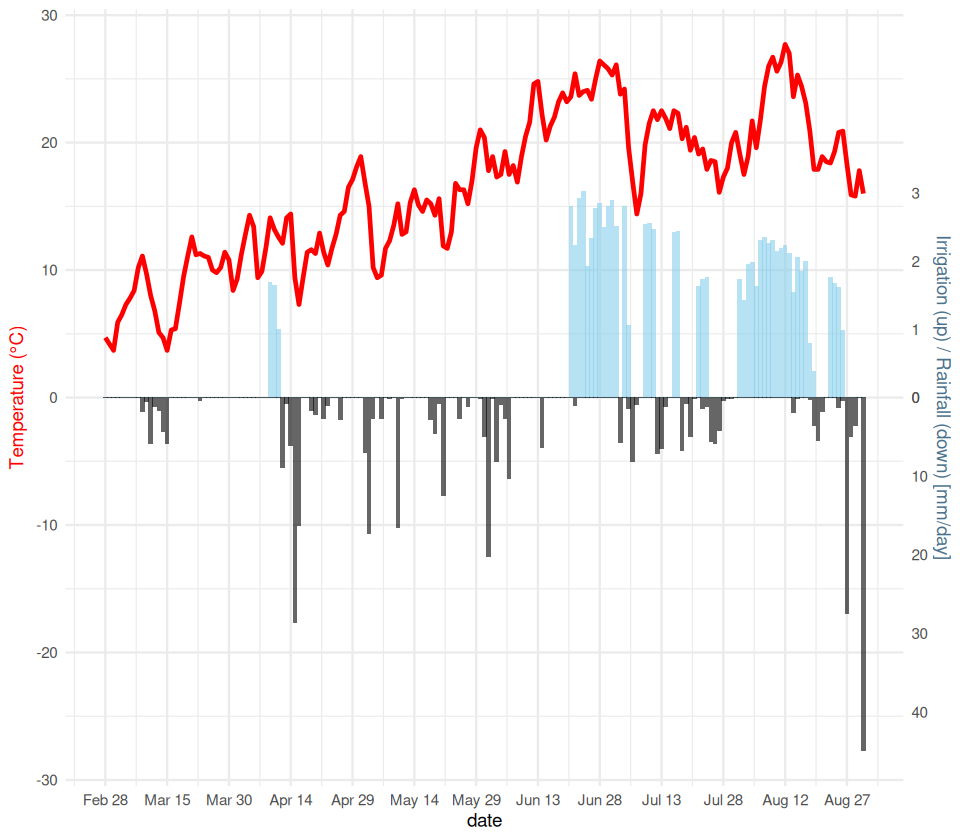

In [1]:
suppressWarnings(
  suppressMessages({
  library(repr)
library(tidyverse)
options(repr.plot.width=8)
source("../Model_irrigation_fun.R")
data_Changins <- read.table("../data/2025_Changins.csv", sep = ";", header = T)
names(data_Changins) <- c("date", "temperature", "rainfall", "solar_radiation", "Evapotranspiration")
data_Changins$date  <- as.POSIXlt(data_Changins$date,format="%d.%m.%Y", tz = "CET")
data_Changins$JulianDay <- data_Changins$date$yday +1 # 1 should corresponds to 1st January 
# with(data_Changins, balance_computation(ET = Evapotranspiration, Rad = solar_radiation, Temp = temperature, Rain = rainfall, DOY = JulianDay))
res <- with(data_Changins, 
            balance_computation(ET = Evapotranspiration, Rad = solar_radiation, Temp = temperature, Rain = rainfall, DOY = JulianDay))
res <- data.frame(date = as.Date(data_Changins$date), JulianDay = data_Changins$JulianDay, res$Irrigation)

df_plot <- res |> filter(date>= "2025-03-01") |> left_join(data_Changins, by = c("date", "JulianDay")) |> mutate(date = as.Date(date))
scaleFactor <- max(df_plot$temperature, na.rm=TRUE) / max(df_plot[,3:7], na.rm=TRUE)
scaleFactorRain <- max(df_plot$temperature, na.rm=TRUE) / max(df_plot$rainfall, na.rm=TRUE)

irrig_ticks   <- c(0, 1, 2, 3)
rainfall_ticks <- seq(from = 0, to = 45, by = 10)

# Compute positions in scaled (temperature) space
irrig_breaks   <- irrig_ticks * scaleFactor
rainfall_breaks <- -rainfall_ticks * scaleFactorRain


ggplot(df_plot, aes(x=date)) +
  geom_col(aes(y = Irrigation_0.5 * scaleFactor), fill="skyblue", alpha=0.6) +
  geom_col(aes(y = -rainfall * scaleFactorRain), fill="black", alpha=0.6) +
  geom_line(aes(y = temperature), color="red", linewidth =1) +
  scale_y_continuous(
    name = "Temperature (°C)",
    sec.axis = sec_axis(
      ~., 
      breaks = c(irrig_breaks, rainfall_breaks),
      labels = c(irrig_ticks, rainfall_ticks),
      name = "Irrigation (up) / Rainfall (down) [mm/day]"
    )
  ) +
  scale_x_date(
    breaks = seq(min(df_plot$date), max(df_plot$date), by="15 days"),
    date_labels = "%b %d"
  ) +
  theme_minimal() +
  theme(
    axis.title.y.left = element_text(color="red"),
    axis.title.y.right = element_text(color="skyblue4")
  )
  
}))
